#Tugas Praktikum 1 — Pengolahan Dataset Big Data Bulan Lain

| Keterangan | Isi |
|---|---|
| Nama | Daffa Aira Adrin |
| NIM | 2411531006 |
| Kelas | A |
| Mata Kuliah | Praktikum Big Data |
| Dataset | NYC TLC Yellow Taxi Trip Records — Juli 2023 (dibandingkan dengan Januari 2023) |
| Sumber | https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page |



#Persiapan

##J-1. Verifikasi Lingkungan Kerja
Dilakukan impor modul sys, platform, dan multiprocessing untuk mencetak versi Python, deskripsi sistem operasi, dan jumlah core CPU yang disediakan runtime Colab. Ketersediaan pustaka pandas, numpy, pyarrow, matplotlib, dan psutil beserta versinya diperiksa melalui perulangan dengan fungsi bawaan \_\_import\_\_(), sedangkan blok except ImportError menampilkan keterangan apabila sebuah pustaka belum terpasang. Versi yang tercetak menjadi acuan seluruh kesimpulan kinerja pada notebook ini karena hasil pengukuran hanya berlaku untuk spesifikasi mesin tersebut.

In [1]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib", "psutil"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
psutil     : 5.9.5


##J-1. Kapasitas RAM, Disk, dan Versi Java
Kapasitas sumber daya runtime diperiksa melalui perintah shell yang dijalankan dari dalam notebook dengan awalan tanda seru, yaitu free -h untuk RAM, df -h /content untuk sisa disk pada direktori kerja, dan java -version untuk memastikan Java tersedia bagi PySpark pada langkah J-8. Total RAM dan sisa disk yang tercetak dicatat sebagai batas sumber daya yang menjadi pembanding ukuran dataset pada refleksi teori.

In [2]:
!free -h            # kapasitas dan sisa RAM
!df -h /content     # kapasitas dan sisa disk runtime
!java -version      # dibutuhkan PySpark pada langkah J-8

               total        used        free      shared  buff/cache   available
Mem:            12Gi       940Mi       9.0Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.024s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.024s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


##J-2. Menghubungkan Google Drive dan Menyiapkan Struktur Folder
Google Drive disambungkan ke runtime melalui drive.mount() agar artefak hasil tidak hilang ketika runtime berakhir. Dua direktori ditetapkan, yaitu DIR_KERJA pada /content/data sebagai tempat kerja sementara yang cepat dan DIR_SIMPAN pada folder BigData/Praktikum1/Tugas1 di Drive sebagai penyimpanan permanen; keduanya dibuat dengan os.makedirs() berparameter exist_ok=True sehingga sel aman dijalankan berulang kali. Isi DIR_SIMPAN ditampilkan dengan os.listdir() sebagai verifikasi bahwa penyambungan berhasil.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA  = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1/Tugas1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
[]


##J-3. Menyiapkan Alat Ukur Waktu dan Memori
Objek proses dibentuk dari psutil.Process(os.getpid()) agar pemakaian memori fisik (RSS) proses notebook dapat dibaca, dan list catatan disiapkan sebagai penampung seluruh hasil pengukuran. Fungsi rss_mb() mengembalikan RSS dalam satuan MB, sedangkan fungsi ukur() menjalankan sebuah fungsi tanpa argumen sambil mencatat durasi dengan time.perf_counter() dan selisih RSS sebelum dan sesudah eksekusi. Setiap pemanggilan ukur() menambahkan satu baris ke catatan dengan label yang unik karena label tersebut nantinya menjadi kolom langkah pada berkas pengukuran_kinerja.csv.

In [4]:
import time, os, psutil

proses  = psutil.Process(os.getpid())
catatan = []            # menyimpan hasil pengukuran untuk dibandingkan nanti

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil  = fungsi()
    detik  = time.perf_counter() - t0
    delta  = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

##Konfigurasi Notebook
Seluruh konstanta yang dipakai di sepanjang notebook dikumpulkan pada satu sel agar penggantian bulan cukup dilakukan di satu tempat. URL_DASAR menyimpan alamat server berkas TLC, BULAN_TUGAS dan BULAN_PRAKTIKUM menentukan dua bulan yang diolah, dan nama serta lokasi berkas untuk kedua bulan dibentuk dari keduanya dengan os.path.join() di dalam DIR_KERJA. KOLOM memuat delapan kolom yang dibutuhkan sesuai modul, sedangkan UKURAN_CHUNK menetapkan jumlah baris per potongan pada langkah *chunking*.

In [5]:
URL_DASAR       = "https://d37ci6vzurychx.cloudfront.net/trip-data/"
BULAN_TUGAS     = "2023-07"            # bulan yang dipilih untuk tugas
BULAN_PRAKTIKUM = "2023-01"            # bulan pada praktikum, sebagai pembanding

FILE_TUGAS      = f"yellow_tripdata_{BULAN_TUGAS}.parquet"
FILE_PRAKTIKUM  = f"yellow_tripdata_{BULAN_PRAKTIKUM}.parquet"
URL_TUGAS       = URL_DASAR + FILE_TUGAS
URL_PRAKTIKUM   = URL_DASAR + FILE_PRAKTIKUM
PATH_TUGAS      = os.path.join(DIR_KERJA, FILE_TUGAS)
PATH_PRAKTIKUM  = os.path.join(DIR_KERJA, FILE_PRAKTIKUM)
CSV             = os.path.join(DIR_KERJA, f"trips_{BULAN_TUGAS}.csv")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]
UKURAN_CHUNK = 500_000

print("File tugas     :", PATH_TUGAS)
print("File praktikum :", PATH_PRAKTIKUM)

File tugas     : /content/data/yellow_tripdata_2023-07.parquet
File praktikum : /content/data/yellow_tripdata_2023-01.parquet


#Tugas 1. Ganti Dataset — Juli 2023

##J-4. Mengunduh Dataset Juli 2023
Berkas Parquet bulan Juli 2023 diunduh dari server resmi TLC dengan urllib.request.urlretrieve() yang dibungkus fungsi ukur() agar durasi unduhan tercatat; pengunduhan dikondisikan dengan os.path.exists() sehingga berkas tidak diunduh ulang apabila sudah ada di DIR_KERJA. Ukuran berkas dicetak dalam MB melalui os.path.getsize() bersama alamat sumber dan tanggal eksekusi sel dari time.strftime() sebagai bagian dari keterangan sumber data yang wajib dicantumkan pada laporan.

In [6]:
import urllib.request

if not os.path.exists(PATH_TUGAS):
    ukur("unduh dataset 2023-07", lambda: urllib.request.urlretrieve(URL_TUGAS, PATH_TUGAS))

print("Sumber        :", URL_TUGAS)
print("Tanggal unduh :", time.strftime("%Y-%m-%d"))
print("Ukuran file   :", round(os.path.getsize(PATH_TUGAS) / 1024**2, 1), "MB")

[unduh dataset 2023-07] 1.69 s | RSS +1.8 MB
Sumber        : https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet
Tanggal unduh : 2026-09-12
Ukuran file   : 46.1 MB


##J-4. Inspeksi Metadata Parquet dan Pemeriksaan Kolom
Metadata berkas dibaca melalui pq.ParquetFile() tanpa memuat satu baris pun ke memori untuk memperoleh jumlah baris, jumlah kolom, jumlah *row group*, dan daftar nama kolom. Karena nama kolom pada bulan lain dapat berbeda, setiap nama pada KOLOM diperiksa keberadaannya di dalam schema.names dan nama yang tidak ditemukan dikumpulkan ke dalam list kolom_hilang. List tersebut harus kosong agar langkah selanjutnya dapat memakai KOLOM tanpa perubahan; jika tidak kosong, nama kolom pada sel konfigurasi harus disesuaikan sebelum melanjutkan.

In [7]:
import pyarrow.parquet as pq

meta       = pq.ParquetFile(PATH_TUGAS).metadata
nama_kolom = pq.ParquetFile(PATH_TUGAS).schema.names
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", nama_kolom)

kolom_hilang = []
for kol in KOLOM:
    if kol not in nama_kolom:
        kolom_hilang.append(kol)
print("Kolom KOLOM yang tidak ada di file:", kolom_hilang)

Jumlah baris : 2,907,108
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']
Kolom KOLOM yang tidak ada di file: []


##J-5. Memuat Data dan Mengukur Biaya Memorinya
Dua percobaan pemuatan dilakukan dan diukur dengan ukur(), yaitu pd.read_parquet() atas seluruh kolom, lalu atas kolom terpilih saja melalui argumen columns=KOLOM. Pemakaian memori tiap hasil dihitung dengan memory_usage(deep=True).sum() dan disimpan pada memori_penuh dan memori_terpilih agar dapat dirujuk kembali pada refleksi teori. Objek penuh dihapus dengan del dan gc.collect() dipanggil sebelum percobaan kedua supaya pengukuran kedua tidak terpengaruh memori percobaan pertama, kemudian lima baris pertama ditampilkan dengan head().

In [8]:
import pandas as pd

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH_TUGAS))
memori_penuh = penuh.memory_usage(deep=True).sum() / 1024**2
print("Dimensi:", penuh.shape)
print("Memori :", round(memori_penuh, 1), "MB")

del penuh                                       # bebaskan memori sebelum percobaan kedua
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH_TUGAS, columns=KOLOM))
memori_terpilih = df.memory_usage(deep=True).sum() / 1024**2
print("Dimensi:", df.shape)
print("Memori :", round(memori_terpilih, 1), "MB")
df.head()

[baca semua kolom] 4.49 s | RSS +466.7 MB
Dimensi: (2907108, 19)
Memori : 502.5 MB
[baca kolom terpilih] 0.80 s | RSS +144.7 MB
Dimensi: (2907108, 8)
Memori : 177.4 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-07-01 00:29:59,2023-07-01 00:40:15,1.0,1.80,1,12.1,5.10,22.20
1,2023-07-01 00:03:25,2023-07-01 00:23:44,1.0,2.31,2,19.1,0.00,24.10
2,2023-07-01 00:38:29,2023-07-01 00:48:53,1.0,2.36,1,13.5,3.70,22.20
3,2023-07-01 00:14:16,2023-07-01 00:29:13,1.0,4.36,1,19.8,4.96,29.76
4,2023-07-01 00:11:15,2023-07-01 00:20:47,0.0,1.60,1,11.4,3.25,19.65


##J-5. Memori per Kolom
Ringkasan tipe data dan pemakaian memori ditampilkan dengan info(memory_usage="deep"), lalu pemakaian memori setiap kolom diurutkan dari yang terbesar dalam satuan MB untuk mengetahui kolom mana yang paling mahal disimpan.

In [9]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2   # MB per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2907108 entries, 0 to 2907107
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 177.4 MB


,0
tpep_pickup_datetime,22.179474
payment_type,22.179474
tpep_dropoff_datetime,22.179474
passenger_count,22.179474
trip_distance,22.179474
tip_amount,22.179474
fare_amount,22.179474
total_amount,22.179474
Index,0.000126


##J-5. Optimasi Tipe Data
Pemakaian memori diturunkan dengan menyempitkan tipe data, yaitu passenger_count serta empat kolom lain menjadi float32, sedangkan trip_distance tetap float64 melalui pd.to_numeric() dengan downcast="float", sedangkan payment_type yang hanya berisi beberapa kode diubah ke int8 lalu ke category. Total memori sebelum dan sesudah dibandingkan beserta persentase penghematannya, dan tipe data akhir ditampilkan melalui dtypes. Penyempitan ke float32 mengurangi presisi sehingga dapat diterima untuk analisis agregat, tetapi tidak untuk perhitungan tagihan.

In [10]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

177.4 MB -> 113.7 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


##J-6. Pemeriksaan Kualitas Data (Veracity)
Kolom durasi_menit dibentuk dari selisih waktu penurunan dan penjemputan yang dikonversi ke menit melalui dt.total_seconds() dibagi 60. Statistik deskriptif kolom trip_distance, durasi_menit, dan total_amount ditampilkan dengan describe(), dan jumlah nilai kosong per kolom dihitung dengan isna().sum(). Empat jenis anomali dihitung dengan *boolean mask* di dalam dictionary anomali, yaitu jarak nol atau negatif, durasi nol atau negatif, durasi lebih dari 180 menit, dan total tarif nol atau negatif, lalu jumlah dan persentasenya terhadap seluruh baris dicetak melalui perulangan.

In [11]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                      df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"          : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"         : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit"  : (df["durasi_menit"]  > 180).sum(),
    "total_amount <= 0"   : (df["total_amount"]  <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   2.907108e+06  2.907108e+06  2.907108e+06
mean    4.489381e+00  1.707664e+01  2.856786e+01
std     2.578832e+02  4.099461e+01  2.446845e+01
min     0.000000e+00 -5.711667e+01 -6.223000e+02
25%     1.060000e+00  7.466667e+00  1.570000e+01
50%     1.810000e+00  1.240000e+01  2.090000e+01
75%     3.580000e+00  2.033333e+01  3.080000e+01
max     1.919450e+05  7.348833e+03  1.079450e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          85086
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 49,790 baris (1.71%)
durasi <= 0           : 1,395 baris (0.05%)
durasi > 180 menit    : 2,760 baris (0.09%)
total_amount <= 0     : 31,240 baris (1.07%)


##J-6. Pembersihan Data
Kriteria kelayakan disusun dalam *boolean mask* layak yang menggabungkan empat kondisi dengan operator &, yaitu jarak lebih dari 0 dan kurang dari 100 mil, durasi antara 1 dan 180 menit melalui between(), serta total tarif positif; setiap perbandingan ditulis di dalam tanda kurung karena operator & berprioritas lebih tinggi daripada operator perbandingan. Baris yang lolos disalin ke DataFrame bersih dengan loc[layak].copy() agar terbentuk objek yang terpisah dari df, kemudian jumlah baris sebelum dan sesudah penyaringan beserta selisihnya dicetak. Batas 180 menit dan 100 mil adalah keputusan analitis untuk menyingkirkan rekaman yang hampir pasti salah catat, bukan kebenaran mutlak.

In [12]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

2,907,108 baris -> 2,817,657 baris  (dibuang 89,451)


##J-7. Menulis Ulang Data sebagai CSV
Kondisi berkas yang lebih besar dari memori disimulasikan dengan menulis DataFrame bersih ke berkas CSV pada lokasi CSV melalui to_csv() berparameter index=False, yang dibungkus ukur() agar waktu tulisnya tercatat. Ukuran berkas Parquet asal dan CSV hasil dibandingkan dengan os.path.getsize() untuk menunjukkan selisih ukuran format kolumnar terkompresi terhadap format teks per baris.

In [13]:
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH_TUGAS) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 36.76 s | RSS +5.2 MB
Parquet: 46.1 MB
CSV    : 213.6 MB


##J-7. Agregasi Bertahap dengan Chunking
Fungsi agregasi_bertahap() membaca CSV dengan pd.read_csv() yang dibatasi pada dua kolom melalui usecols, mengonversi kolom waktu dengan parse_dates, dan memecah berkas menjadi potongan sebesar ukuran_chunk baris melalui chunksize sehingga hanya satu potongan yang berada di memori pada satu waktu. Setiap potongan menambah jumlah baris dan total tarif, sedangkan jumlah dan total per jam diakumulasikan ke dalam dictionary per_jam dengan get() sebagai nilai awal. Fungsi dijalankan lewat ukur() dengan UKURAN_CHUNK sebagai ukuran potongan, lalu rata-rata total_amount dihitung dari hasil akumulasi; kolom delta_rss_mb pada pengukuran inilah yang dibandingkan dengan pemuatan penuh pada laporan kinerja.

In [14]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV, UKURAN_CHUNK))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 5.47 s | RSS +34.2 MB
2,817,657 baris | rata-rata total_amount = 29.04


##J-8. Memasang PySpark
PySpark versi 3.5.1 dipasang melalui pip sesuai versi yang diuji pada modul, dan java -version dijalankan kembali untuk memastikan Java yang tersedia cocok dengan Spark 3.5. Pemasangan dilakukan di dalam notebook agar runtime baru tidak memerlukan persiapan manual.

In [15]:
!pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


##J-8. Membuat SparkSession
SparkSession dibangun melalui pola *builder* dengan appName() sebagai nama aplikasi dan master("local[*]") agar Spark berjalan dalam satu proses memakai seluruh core mesin. Memori driver ditetapkan 4 GB dan spark.sql.shuffle.partitions diturunkan menjadi 8 karena 200 partisi bawaan hanya menambah *overhead* pada data sebesar ini. Dua konfigurasi tambahan, yaitu spark.sql.parquet.inferTimestampNTZ.enabled bernilai false dan spark.sql.session.timeZone bernilai UTC, membuat kolom waktu Parquet dibaca sebagai TIMESTAMP sehingga cast("long") berjalan dan F.hour() membaca jam apa adanya seperti .dt.hour pada pandas. Tingkat log diturunkan ke WARN dan versi Spark dicetak sebagai verifikasi bahwa sesi berhasil dibuat.

In [18]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-T01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.parquet.inferTimestampNTZ.enabled", "false")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


##J-8. Pembersihan dan Agregasi dengan Spark
Berkas Parquet dibaca sebagai Spark DataFrame melalui spark.read.parquet(), skemanya ditampilkan dengan printSchema(), dan jumlah barisnya dihitung dengan count() di dalam ukur(). Kolom durasi_menit dibentuk dengan withColumn() dari selisih kedua kolom waktu yang dikonversi ke long, lalu tiga filter() menerapkan kriteria kelayakan yang sama dengan mask layak pada pandas. Agregasi per jam disusun dengan F.hour(), groupBy(), dan agg(), tetapi karena Spark bersifat *lazy*, seluruh transformasi baru dieksekusi ketika show() dipanggil di dalam ukur() sehingga waktu yang tercatat mencakup pembacaan, penyaringan, dan agregasi sekaligus.

In [19]:
sdf = spark.read.parquet(PATH_TUGAS)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("long")
         - F.col("tpep_pickup_datetime").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count] 0.34 s | RSS +0.0 MB
Jumlah baris: 2907108
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+---+-

##J-8. Kueri SQL per Metode Pembayaran
DataFrame hasil pembersihan didaftarkan sebagai *temporary view* bernama trips melalui createOrReplaceTempView() agar dapat dikueri dengan spark.sql(). Kueri mengelompokkan perjalanan menurut payment_type untuk menghitung jumlah perjalanan serta rata-rata total tarif dan tip, diurutkan dari jumlah terbesar. Rencana eksekusi agregasi per jam ditampilkan dengan explain() untuk mengamati tahap Exchange dan HashAggregate, kemudian sesi ditutup dengan spark.stop() supaya memori JVM dilepas sebelum langkah pandas berikutnya.

In [20]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                    AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()                # bebaskan sumber daya sebelum lanjut

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2202049|     29.82|    4.36|
|           2| 512650|     25.54|     0.0|
|           0|  73668|     31.31|    3.59|
|           4|  19114|     27.03|    0.02|
|           3|  10176|     24.49|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#147 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#147 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=241]
      +- HashAggregate(keys=[jam#147], functions=[count(1), avg(trip_distance#67), avg(total_amount#79)])
         +- Exchange hashpartitioning(jam#147, 8), ENSURE_REQUIREMENTS, [plan_id=238]
            +- HashAggregate(keys=[jam#147], functions=[partial_count(1), partial_avg(trip_distance#67), partial_avg(total_amount#79)])
               +- Project [trip_distance#67, total_amount#79, hour(tpep_pickup_datetime#

##J-9. Agregasi Akhir dengan pandas dan Penyimpanan Artefak
Kolom jam dibentuk dari dt.hour waktu penjemputan, lalu DataFrame bersih dikelompokkan dengan groupby("jam") dan diringkas melalui agg() dengan *named aggregation* menjadi jumlah perjalanan, rata-rata jarak, durasi, dan tarif, serta median tarif per jam; agregasi ini dibungkus ukur() agar waktunya dapat dibandingkan dengan *chunking* dan Spark. Hasil dibulatkan dua desimal, indeksnya dikembalikan menjadi kolom dengan reset_index(), dan tabel agregasi_jul disimpan ke DIR_SIMPAN dalam format CSV dan Parquet bersama tabel catatan sebagai pengukuran_kinerja.csv.

In [21]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi_jul = ukur("agregasi pandas", lambda: bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi_jul.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_{BULAN_TUGAS}.csv", index=False)
agregasi_jul.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_{BULAN_TUGAS}.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi_jul

[agregasi pandas] 0.29 s | RSS -39.4 MB


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


##J-10. Visualisasi Hasil
Diagram batang jumlah perjalanan per jam penjemputan dibuat dengan plt.subplots() dan ax.bar() dari tabel agregasi_jul, dilengkapi label sumbu, judul, dan penanda sumbu X untuk 24 jam melalui set_xticks(). Gambar disimpan ke DIR_SIMPAN sebagai PNG beresolusi 150 dpi dengan fig.savefig() sebelum ditampilkan dengan plt.show(); satu grafik hanya menyampaikan satu pesan sehingga metrik lain tidak ditumpuk pada sumbu yang sama.

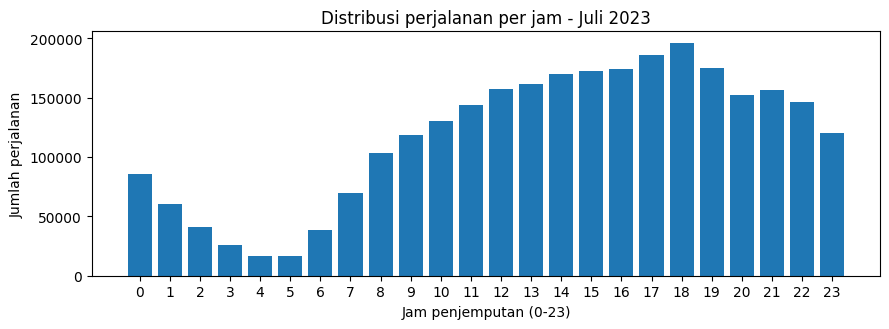

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_jul["jam"], agregasi_jul["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam - Juli 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_{BULAN_TUGAS}.png", dpi=150)
plt.show()

#Tugas 2. Perbandingan Dua Bulan

##Memuat dan Membersihkan Data Januari 2023
Berkas bulan praktikum diunduh dengan cara yang sama seperti J-4 apabila belum ada di DIR_KERJA, lalu hanya kolom pada KOLOM yang dimuat ke df_jan melalui pd.read_parquet() di dalam ukur(). Kolom durasi_menit dibentuk dengan rumus yang sama dan mask layak_jan menerapkan empat kondisi yang identik dengan mask bulan Juli sehingga kedua bulan melewati kriteria pembersihan yang sama dan pola per jamnya dapat dibandingkan secara adil. Jumlah baris sebelum dan sesudah penyaringan dicetak agar proporsi baris yang dibuang dapat dibandingkan dengan bulan Juli.

In [23]:
if not os.path.exists(PATH_PRAKTIKUM):
    ukur("unduh dataset 2023-01", lambda: urllib.request.urlretrieve(URL_PRAKTIKUM, PATH_PRAKTIKUM))
print("Ukuran file:", round(os.path.getsize(PATH_PRAKTIKUM) / 1024**2, 1), "MB")

df_jan = ukur("baca kolom terpilih 2023-01", lambda: pd.read_parquet(PATH_PRAKTIKUM, columns=KOLOM))
df_jan["durasi_menit"] = (df_jan["tpep_dropoff_datetime"] -
                          df_jan["tpep_pickup_datetime"]).dt.total_seconds() / 60

layak_jan = (
    (df_jan["trip_distance"] > 0) & (df_jan["trip_distance"] < 100) &
    df_jan["durasi_menit"].between(1, 180) &
    (df_jan["total_amount"] > 0)
)
bersih_jan = df_jan.loc[layak_jan].copy()
print(f"{len(df_jan):,} baris -> {len(bersih_jan):,} baris  (dibuang {len(df_jan)-len(bersih_jan):,})")

[unduh dataset 2023-01] 0.27 s | RSS +0.0 MB
Ukuran file: 45.5 MB
[baca kolom terpilih 2023-01] 1.30 s | RSS +214.1 MB
3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


##Agregasi per Jam Januari 2023
Tabel agregasi_jan dibentuk dengan groupby("jam") dan *named aggregation* yang sama persis dengan J-9 di dalam ukur() berlabel berbeda agar waktunya tercatat terpisah. Setelah tabel terbentuk, df_jan dan bersih_jan dihapus dengan del dan gc.collect() karena hanya tabel agregasi 24 baris yang diperlukan pada langkah berikutnya.

In [24]:
bersih_jan["jam"] = bersih_jan["tpep_pickup_datetime"].dt.hour

agregasi_jan = ukur("agregasi pandas 2023-01", lambda: bersih_jan
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

del df_jan, bersih_jan                          # bebaskan memori, hanya tabel agregasi yang dipakai
gc.collect()
agregasi_jan

[agregasi pandas 2023-01] 0.50 s | RSS +0.1 MB


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.86,21.60
1,1,57766,3.53,12.63,26.45,21.20
2,2,40445,3.28,12.07,25.06,20.52
3,3,26146,3.58,12.15,26.26,20.99
4,4,16618,4.79,13.52,31.72,22.70
5,5,16940,6.03,14.70,36.75,22.04
6,6,42300,4.80,14.49,30.63,18.48
7,7,84569,3.69,14.42,26.89,18.48
8,8,114064,3.08,14.33,25.21,19.10
9,9,127988,3.09,14.23,25.51,19.25


##Tabel Perbandingan per Jam
Kedua tabel agregasi digabungkan dengan merge() pada kolom jam memakai akhiran \_jan dan \_jul untuk membedakan asal kolom. Kolom selisih_jumlah dihitung sebagai jumlah perjalanan Juli dikurangi Januari, sedangkan persen_perubahan menyatakan selisih tersebut relatif terhadap Januari dalam persen yang dibulatkan dua desimal. Tabel banding disimpan ke DIR_SIMPAN sebagai perbandingan_per_jam_2023-01_vs_2023-07.csv, lalu ditampilkan.

In [25]:
banding = agregasi_jan.merge(agregasi_jul, on="jam", suffixes=("_jan", "_jul"))
banding["selisih_jumlah"]   = banding["jumlah_perjalanan_jul"] - banding["jumlah_perjalanan_jan"]
banding["persen_perubahan"] = (100 * banding["selisih_jumlah"] / banding["jumlah_perjalanan_jan"]).round(2)

banding.to_csv(f"{DIR_SIMPAN}/perbandingan_per_jam_{BULAN_PRAKTIKUM}_vs_{BULAN_TUGAS}.csv", index=False)
banding

,jam,jumlah_perjalanan_jan,rata_jarak_jan,rata_durasi_jan,rata_tarif_jan,median_tarif_jan,jumlah_perjalanan_jul,rata_jarak_jul,rata_durasi_jul,rata_tarif_jul,median_tarif_jul,selisih_jumlah,persen_perubahan
0,0,82289,4.04,13.57,28.86,21.60,85987,4.45,14.82,31.049999,22.200001,3698,4.49
1,1,57766,3.53,12.63,26.45,21.20,59980,4.04,13.52,28.639999,21.360001,2214,3.83
2,2,40445,3.28,12.07,25.06,20.52,40812,3.79,12.82,27.080000,21.100000,367,0.91
3,3,26146,3.58,12.15,26.26,20.99,26000,4.02,12.83,27.920000,21.299999,-146,-0.56
4,4,16618,4.79,13.52,31.72,22.70,16637,5.60,14.62,34.919998,24.100000,19,0.11
5,5,16940,6.03,14.70,36.75,22.04,16913,6.67,15.65,39.740002,23.900000,-27,-0.16
6,6,42300,4.80,14.49,30.63,18.48,38422,5.11,14.51,32.130001,19.250000,-3878,-9.17
7,7,84569,3.69,14.42,26.89,18.48,69358,4.10,14.57,28.600000,18.799999,-15211,-17.99
8,8,114064,3.08,14.33,25.21,19.10,103647,3.53,15.30,27.340000,19.320000,-10417,-9.13
9,9,127988,3.09,14.23,25.51,19.25,118788,3.40,15.68,27.280001,19.900000,-9200,-7.19


##Grafik Perbandingan per Jam
Satu gambar dibuat dengan dua pemanggilan ax.bar() berlebar 0,4 yang digeser 0,2 ke kiri untuk Januari dan 0,2 ke kanan untuk Juli sehingga batang kedua bulan berdampingan pada setiap jam. Sumbu, judul, dan legenda diberi label, kemudian gambar disimpan ke DIR_SIMPAN sebagai PNG dan ditampilkan; hanya jumlah perjalanan yang digambar karena satu grafik hanya menyampaikan satu pesan.

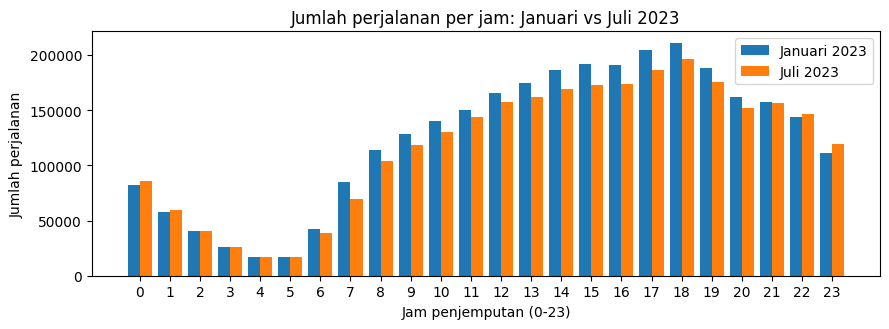

In [26]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(banding["jam"] - 0.2, banding["jumlah_perjalanan_jan"], width=0.4, label="Januari 2023")
ax.bar(banding["jam"] + 0.2, banding["jumlah_perjalanan_jul"], width=0.4, label="Juli 2023")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Jumlah perjalanan per jam: Januari vs Juli 2023")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_per_jam_{BULAN_PRAKTIKUM}_vs_{BULAN_TUGAS}.png", dpi=150)
plt.show()

#Tugas 3. Laporan Kinerja

##Tabel Pengukuran Kinerja
Seluruh isi list catatan dikonversi ke DataFrame kinerja dan disimpan ulang sebagai pengukuran_kinerja.csv di DIR_SIMPAN agar pengukuran setelah J-9, termasuk pemuatan dan agregasi bulan Januari, ikut terlampir. Tabel ditampilkan terurut menurun berdasarkan kolom detik sehingga langkah termahal berada di baris teratas.

In [27]:
kinerja = pd.DataFrame(catatan)
kinerja.to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
kinerja.sort_values("detik", ascending=False)

,langkah,detik,delta_rss_mb
3,tulis CSV,36.76,5.2
7,spark agregasi,6.73,0.0
5,spark count,5.96,0.0
4,agregasi chunking,5.47,34.2
1,baca semua kolom,4.49,466.7
0,unduh dataset 2023-07,1.69,1.8
10,baca kolom terpilih 2023-01,1.30,214.1
2,baca kolom terpilih,0.80,144.7
11,agregasi pandas 2023-01,0.50,0.1
6,spark count,0.34,0.0


##Pembahasan
Berdasarkan tabel di atas, langkah yang paling mahal adalah tulis CSV dengan waktu 36,76 detik dan pertumbuhan RSS 5,2 MB, sedangkan langkah termahal kedua adalah spark agregasi dengan 6,73 detik. Sebagai pembanding, pembacaan kolom terpilih hanya memerlukan 0,80 detik sehingga langkah termahal memakan sekitar 46 kali waktu pembacaan data yang sebenarnya dibutuhkan. Langkah spark count tercatat dua kali (5,96 dan 0,34 detik) karena selnya dijalankan dua kali; selisih keduanya menunjukkan bahwa pengukuran pertama memuat biaya inisialisasi yang tidak terulang pada pemanggilan kedua.

Perubahan konkret yang diusulkan adalah tidak menulis CSV sama sekali dan mengagregasi langsung dari Parquet melalui pq.ParquetFile(PATH_TUGAS).iter_batches() dengan argumen batch_size dan columns, karena format teks memaksa setiap nilai diubah menjadi *string* tanpa kompresi sehingga berkasnya membengkak menjadi 213,6 MB atau 4,6 kali ukuran Parquet, sedangkan pembacaan per *batch* dari Parquet hanya menyentuh kolom yang diminta dan tetap mengalir sepotong demi sepotong meskipun berkas ini hanya memiliki satu *row group*. Dengan cara itu, 36,76 detik penulisan CSV hilang seluruhnya; agregasi bertahap dari Parquet diperkirakan setara dengan pembacaan kolom terpilih (0,80 detik) ditambah agregasi pandas (0,29 detik), yakni sekitar satu detik, dan angka pastinya baru dapat dipastikan dengan pengukuran ukur() yang sama.

#Tugas 4. Refleksi Teori

##Ringkasan Angka untuk Refleksi
Angka yang dibutuhkan refleksi dikumpulkan dari variabel yang sudah dihitung pada langkah sebelumnya, yaitu jumlah baris, jumlah kolom, dan ukuran Parquet dari J-4, ukuran CSV dari J-7, memori semua kolom, kolom terpilih, dan setelah optimasi tipe dari J-5, persentase tiap anomali dan jumlah baris yang dibuang dari J-6, serta jam tersibuk dan tersepi dari agregasi_jul dan perubahan terbesar dari banding. Hanya total RAM yang dibaca baru melalui psutil.virtual_memory(), dan tabel kinerja dicetak ulang agar waktu agregasi pandas, *chunking*, dan Spark dapat dibaca berdampingan.

In [28]:
ram_total_gb   = psutil.virtual_memory().total / 1024**3
ukuran_parquet = os.path.getsize(PATH_TUGAS) / 1024**2
ukuran_csv     = os.path.getsize(CSV) / 1024**2
dibuang        = len(df) - len(bersih)
urut_jul       = agregasi_jul.sort_values("jumlah_perjalanan")
urut_banding   = banding.sort_values("persen_perubahan")

print("Jumlah baris file        :", f"{meta.num_rows:,}")
print("Jumlah kolom file        :", meta.num_columns, "| kolom hilang:", kolom_hilang)
print("Ukuran Parquet           :", f"{ukuran_parquet:.1f} MB")
print("Ukuran CSV               :", f"{ukuran_csv:.1f} MB  ({ukuran_csv/ukuran_parquet:.1f} kali Parquet)")
print("Memori semua kolom       :", f"{memori_penuh:.1f} MB  ({memori_penuh/ukuran_parquet:.1f} kali ukuran file)")
print("Memori kolom terpilih    :", f"{memori_terpilih:.1f} MB")
print("Memori setelah optimasi  :", f"{sesudah:.1f} MB")
print("Total RAM runtime        :", f"{ram_total_gb:.1f} GB  (memori semua kolom = {100*memori_penuh/1024/ram_total_gb:.1f}% RAM)")
print("Jumlah core CPU          :", multiprocessing.cpu_count())
print("Baris dibuang            :", f"{dibuang:,} dari {len(df):,} ({100*dibuang/len(df):.2f}%)")
for k, v in anomali.items():
    print(f"    {k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")
print("Jam tersepi Juli         :", f"pukul {urut_jul['jam'].iloc[0]} ({urut_jul['jumlah_perjalanan'].iloc[0]:,} perjalanan)")
print("Jam tersibuk Juli        :", f"pukul {urut_jul['jam'].iloc[-1]} ({urut_jul['jumlah_perjalanan'].iloc[-1]:,} perjalanan)")
print("Perubahan Jan->Jul       :", f"terendah jam {urut_banding['jam'].iloc[0]} ({urut_banding['persen_perubahan'].iloc[0]:+.2f}%),",
      f"tertinggi jam {urut_banding['jam'].iloc[-1]} ({urut_banding['persen_perubahan'].iloc[-1]:+.2f}%)")
print()
print(kinerja.sort_values("detik", ascending=False).to_string(index=False))

Jumlah baris file        : 2,907,108
Jumlah kolom file        : 19 | kolom hilang: []
Ukuran Parquet           : 46.1 MB
Ukuran CSV               : 213.6 MB  (4.6 kali Parquet)
Memori semua kolom       : 502.5 MB  (10.9 kali ukuran file)
Memori kolom terpilih    : 177.4 MB
Memori setelah optimasi  : 113.7 MB
Total RAM runtime        : 12.7 GB  (memori semua kolom = 3.9% RAM)
Jumlah core CPU          : 2
Baris dibuang            : 89,451 dari 2,907,108 (3.08%)
    jarak <= 0            : 49,790 baris (1.71%)
    durasi <= 0           : 1,395 baris (0.05%)
    durasi > 180 menit    : 2,760 baris (0.09%)
    total_amount <= 0     : 31,240 baris (1.07%)
Jam tersepi Juli         : pukul 4 (16,637 perjalanan)
Jam tersibuk Juli        : pukul 18 (195,988 perjalanan)
Perubahan Jan->Jul       : terendah jam 7 (-17.99%), tertinggi jam 23 (+7.57%)

                    langkah  detik  delta_rss_mb
                  tulis CSV  36.76           5.2
             spark agregasi   6.73           0.0
   

##Refleksi: Pada Dimensi Mana Dataset Ini Benar-Benar Big
Modul menegaskan bahwa "big" adalah pernyataan tentang hubungan antara data dan sumber daya sehingga setiap dimensi V harus diukur, bukan diperdebatkan. Refleksi berikut menilai lima dimensi tersebut satu per satu dengan angka dari ringkasan di atas; seluruh angka berasal dari keluaran eksekusi notebook ini dengan angka dari ringkasan di atas.

Pada dimensi Volume, dataset ini besar menurut kebiasaan kerja sehari-hari, tetapi tidak besar bagi mesin yang dipakai. Berkas Parquet Juli 2023 berisi 2.907.108 baris dengan ukuran 46,1 MB di disk, dan ketika semua kolom dimuat, memorinya menjadi 502,5 MB, yakni sekitar 10,9 kali ukuran berkasnya. Angka itu setara dengan 3,9% dari total RAM runtime sebesar 12,7 GB; selama nilainya masih di bawah sepertiga RAM, menurut tingkatan pada bagian F.2 modul, data ini termasuk kategori muat di memori dan pandas biasa sudah memadai. Volume baru terasa ketika format diubah menjadi CSV berukuran 213,6 MB, yaitu 4,6 kali Parquet, dan pada titik itulah *chunking* menjadi relevan dengan pertumbuhan RSS hanya 34,2 MB dibandingkan 466,7 MB pada pemuatan penuh.

Pada dimensi Velocity, dataset ini tidak besar. Data diterbitkan TLC satu berkas per bulan dan diunduh sekali dalam 1,69 detik sehingga tidak ada aliran data yang harus diproses dengan latensi tertentu; seluruh pengolahan bersifat *batch* atas data yang sudah diam.

Pada dimensi Variety, dataset ini juga tidak besar karena seluruh kolomnya terstruktur dengan skema tetap berisi 19 kolom bertipe waktu, bilangan, dan kode, dan pemeriksaan kolom_hilang pada J-4 menghasilkan list kosong. Perbedaan yang terukur hanya terletak pada format penyimpanan dan rincian skema antarbulan, misalnya kolom biaya bandara yang bernama airport_fee pada berkas Januari tetapi Airport_fee pada berkas Juli, bukan pada keragaman bentuk data.

Pada dimensi Veracity, dataset ini benar-benar menuntut perlakuan data besar. Dari 2.907.108 baris, sebanyak 89.451 baris (3,08%) dibuang oleh mask layak; anomali terbanyak adalah jarak nol atau negatif sebesar 1,71%, disusul total tarif nol atau negatif sebesar 1,07%. Anomali nyata seperti jarak nol dan durasi negatif berarti hasil agregasi tidak dapat dipercaya tanpa tahap pembersihan yang batasnya dipertanggungjawabkan, dan proporsi baris yang dibuang harus dilaporkan karena berpotensi menggeser rata-rata jarak.

Pada dimensi Value, nilai dataset terbukti pada tabel pola permintaan per jam: jam tersibuk bulan Juli adalah pukul 18 dengan 195.988 perjalanan dan jam tersepi pukul 4 dengan 16.637 perjalanan, sedangkan perbandingan dengan Januari menunjukkan penurunan terbesar sebesar 17,99% pada pukul 7 dan kenaikan terbesar sebesar 7,57% pada pukul 23. Nilai itu diperoleh dengan agregasi pandas dalam 0,29 detik (ditambah 0,80 detik pemuatan kolom terpilih), sementara Spark memerlukan 5,96 detik untuk count pada pemanggilan pertama (0,34 detik saat diulang) dan 6,73 detik untuk agregasi yang sudah mencakup pembacaan dan penyaringan; karena waktu Spark tetap lebih besar, seperti yang diperkirakan modul untuk data sebesar ini, alat terdistribusi justru menambah *overhead* pada skala satu bulan.

Kesimpulannya, dataset ini *big* pada dimensi Veracity dan, secara bersyarat, pada dimensi Volume ketika format dan cara pemuatan dipilih dengan buruk, tetapi tidak *big* pada dimensi Velocity dan Variety. Keputusan alat harus mengikuti angka pengukuran, bukan asumsi bahwa jutaan baris otomatis memerlukan klaster.

#Tugas 5. Reproducibility

##Jaminan Eksekusi pada Runtime Bersih
Beberapa hal dilakukan agar notebook ini dapat dijalankan dari sel pertama sampai sel terakhir pada runtime baru melalui *Runtime → Restart and run all*.
1. Seluruh impor pustaka dilakukan di dalam notebook pada sel tempat pustaka itu pertama dipakai, dan PySpark dipasang lewat pip di dalam notebook sehingga tidak ada persiapan di luar notebook.
2. Semua konstanta didefinisikan pada sel konfigurasi sebelum dipakai, dan tidak ada variabel yang bergantung pada notebook praktikum atau sesi sebelumnya.
3. Kedua unduhan dijaga dengan os.path.exists() sehingga berkas yang sudah ada tidak diunduh ulang, tetapi tetap diunduh otomatis pada runtime yang kosong.
4. Direktori kerja dan penyimpanan dibuat dengan os.makedirs() berparameter exist_ok=True sehingga sel J-2 aman dijalankan berulang.
5. Sesi Spark ditutup dengan spark.stop() dan DataFrame besar bulan Januari dihapus setelah diagregasi agar memori mencukupi sampai sel terakhir.
6. Satu-satunya interaksi yang tersisa adalah dialog izin drive.mount() pada J-2, yang juga diwajibkan modul untuk menyimpan artefak secara permanen.

note: percobaan pertama berhenti setelah count() karena galat cast sebelum konfigurasi ditambahkan

##Pemeriksaan Artefak di Google Drive
Isi DIR_SIMPAN didaftar dengan os.listdir() beserta ukuran tiap berkas dari os.path.getsize() agar keberadaan seluruh artefak, yaitu tabel agregasi per jam Juli dalam CSV dan Parquet, tabel perbandingan, tabel pengukuran kinerja, dan dua gambar PNG, dapat dipastikan sebelum runtime berakhir.

In [29]:
for nama in sorted(os.listdir(DIR_SIMPAN)):
    print(f"{nama:50s} {os.path.getsize(os.path.join(DIR_SIMPAN, nama)) / 1024:8.1f} KB")

agregasi_per_jam_2023-07.csv                            0.8 KB
agregasi_per_jam_2023-07.parquet                        4.7 KB
distribusi_per_jam_2023-07.png                         36.5 KB
pengukuran_kinerja.csv                                  0.3 KB
perbandingan_per_jam_2023-01_vs_2023-07.csv             1.9 KB
perbandingan_per_jam_2023-01_vs_2023-07.png            42.3 KB
